# Exercise 5 — KNN, NBNN and Logistic Regression on Kaktovik Symbols

This notebook reproduces the evaluation from `main.py` and answers the three
discussion questions of Exercise 5:

1. Did Euclidean and cosine distance behave similarly?
2. Did KNN and NBNN differ noticeably on the Kaktovik symbols?
3. Which classifier worked best on the large test split?

All classifiers are **trained on `images/train`**, quantitatively evaluated on the
**full official test split `images/test`**, and the 11 nearest-neighbour plots come
from `images/unit_test`.

## 1. Setup

In [1]:
import sys
from pathlib import Path

# Make the `ex_5` package importable when running from ex_5/notebooks/.
REPO_ROOT = Path.cwd().resolve()
while not (REPO_ROOT / "ex_5").exists() and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

from ex_5.main import main, OUTPUT_DIR
print("Repo root:", REPO_ROOT)

Repo root: /Users/mohammad/Documents/GitHub/IntroML


## 2. Run the full evaluation pipeline

`main()` loads the dataset, trains all five classifier variants on the training
split, evaluates them on the **full** test split (968 images, 11 classes),
generates the 11 KNN neighbour plots, the confusion-matrix plots, and the accuracy
comparison plot into `ex_5/outputs/`, and returns the accuracy dictionary.

In [2]:
accuracies = main()

Loading training data...
Loading test data...
Loading unit-test data...
Dataset sizes: train=2882, test=968, unit_test=11
Evaluating on the full test split.
Creating 11 KNN neighbour plots from the unit-test set...
Running KNN (euclidean)...
Accuracy (KNN (euclidean)): 0.7335
Running KNN (cosine)...
Accuracy (KNN (cosine)): 0.7097
Running NBNN (euclidean)...
Accuracy (NBNN (euclidean)): 0.7696
Running NBNN (cosine)...
Accuracy (NBNN (cosine)): 0.7552
Running Logistic Regression...
Accuracy (logistic): 0.9070
Unit-test accuracy of KNN (euclidean): 0.6364
Saved plots to: /Users/mohammad/Documents/GitHub/IntroML/ex_5/outputs


## 3. Accuracy comparison

In [3]:
order = [
    "KNN (euclidean)",
    "KNN (cosine)",
    "NBNN (euclidean)",
    "NBNN (cosine)",
    "Logistic Regression",
]

print(f"{'Classifier':<22}{'Accuracy':>10}")
print("-" * 32)
for name in order:
    print(f"{name:<22}{accuracies[name]:>10.4f}")

best = max(accuracies, key=accuracies.get)
print("-" * 32)
print(f"Best on test split: {best} ({accuracies[best]:.4f})")

Classifier              Accuracy
--------------------------------
KNN (euclidean)           0.7335
KNN (cosine)              0.7097
NBNN (euclidean)          0.7696
NBNN (cosine)             0.7552
Logistic Regression       0.9070
--------------------------------
Best on test split: Logistic Regression (0.9070)


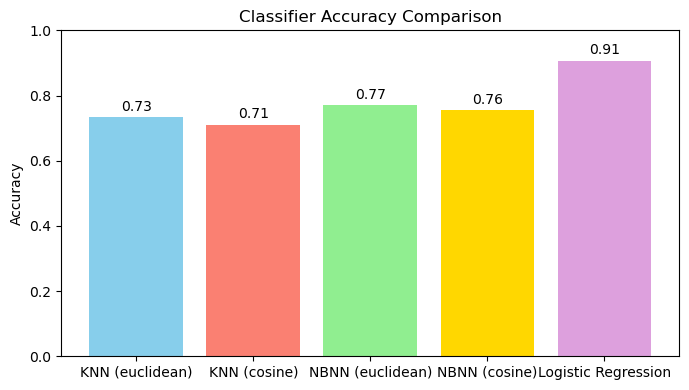

In [4]:
display(Image(filename=str(OUTPUT_DIR / "accuracy_comparison.png")))

## 4. Confusion matrices

One confusion matrix per classifier variant, computed on the full test split with
the NumPy-only `confusion_matrix` from `evaluation.py`.

KNN (euclidean)


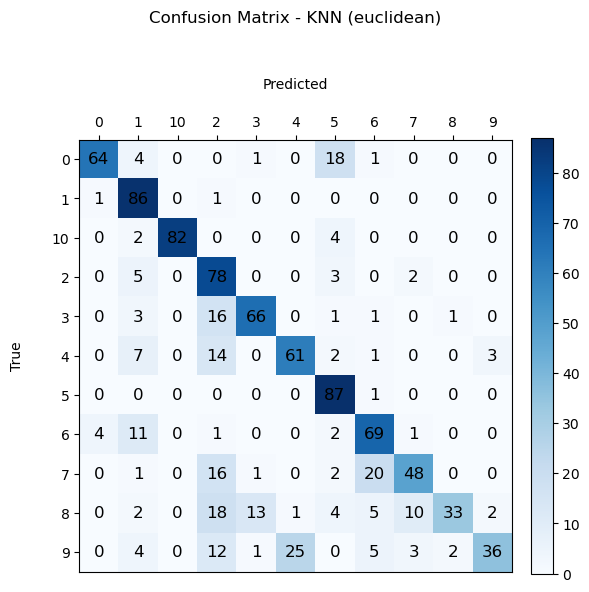

KNN (cosine)


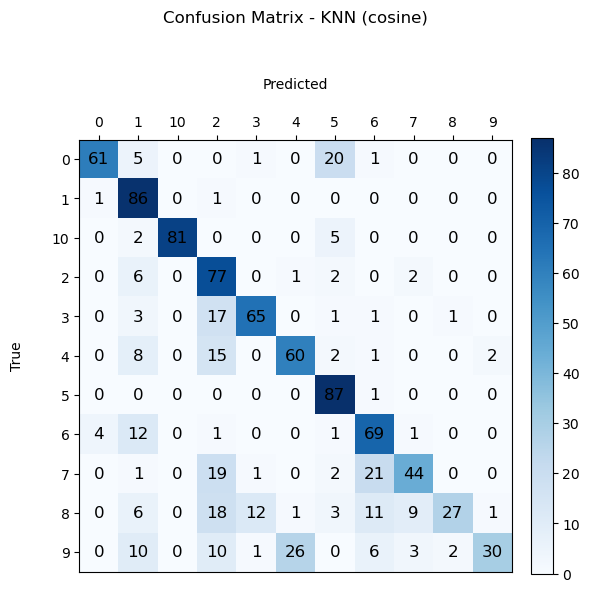

NBNN (euclidean)


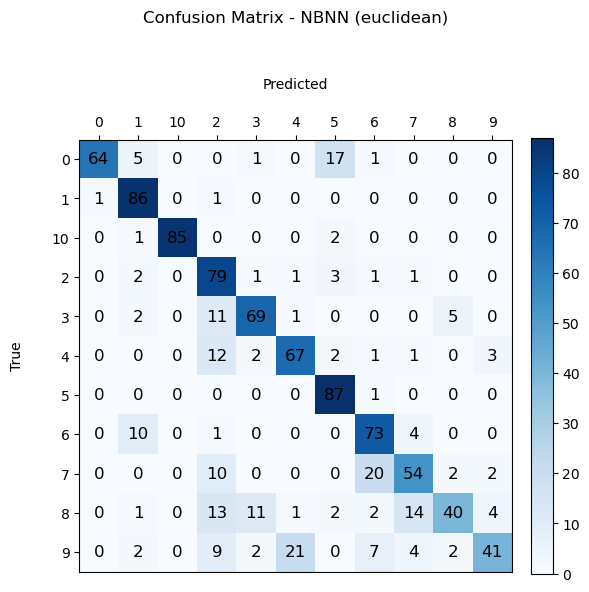

NBNN (cosine)


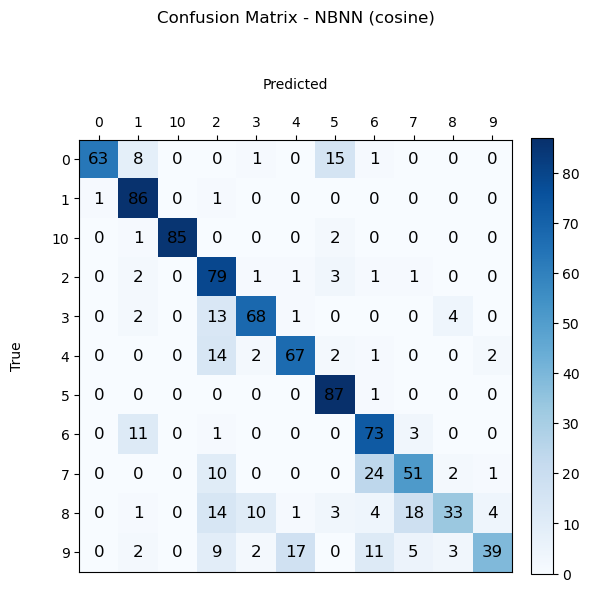

Logistic Regression


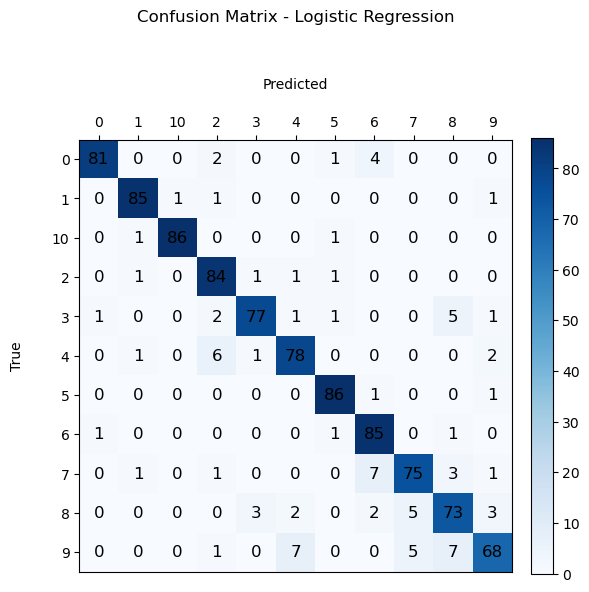

In [5]:
cm_files = {
    "KNN (euclidean)": "confusion_knn_euclidean.png",
    "KNN (cosine)": "confusion_knn_cosine.png",
    "NBNN (euclidean)": "confusion_nbnn_euclidean.png",
    "NBNN (cosine)": "confusion_nbnn_cosine.png",
    "Logistic Regression": "confusion_logistic_regression.png",
}
for name, fname in cm_files.items():
    print(name)
    display(Image(filename=str(OUTPUT_DIR / fname)))

## 5. KNN nearest-neighbour visualizations (unit-test set)

For each of the 11 unit-test symbols, the test image is shown next to its 3 nearest
training neighbours (Euclidean KNN).

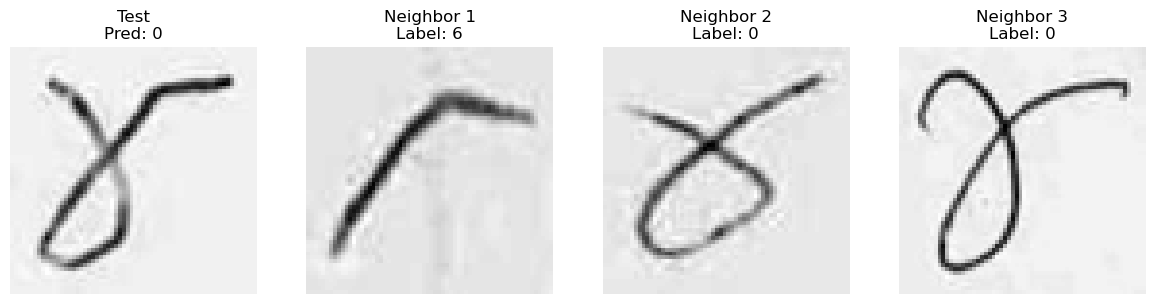

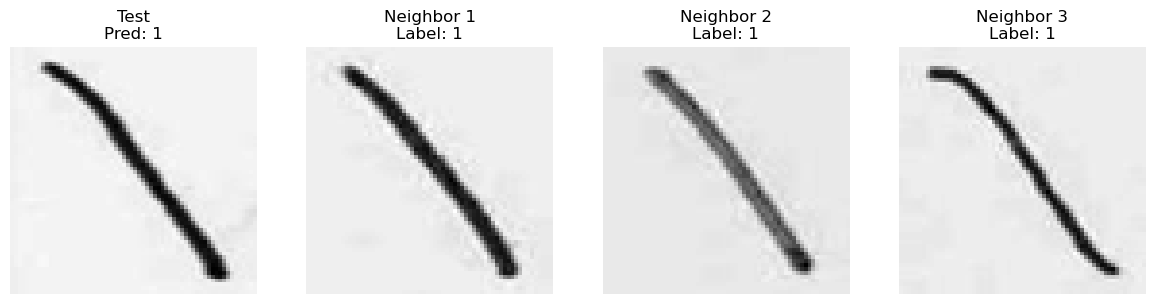

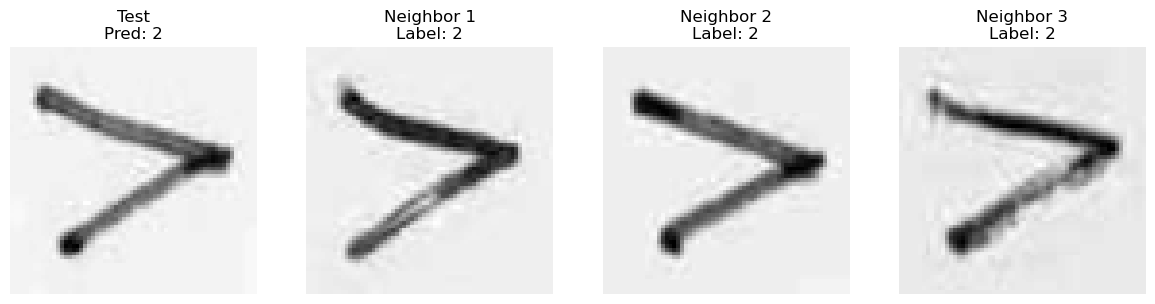

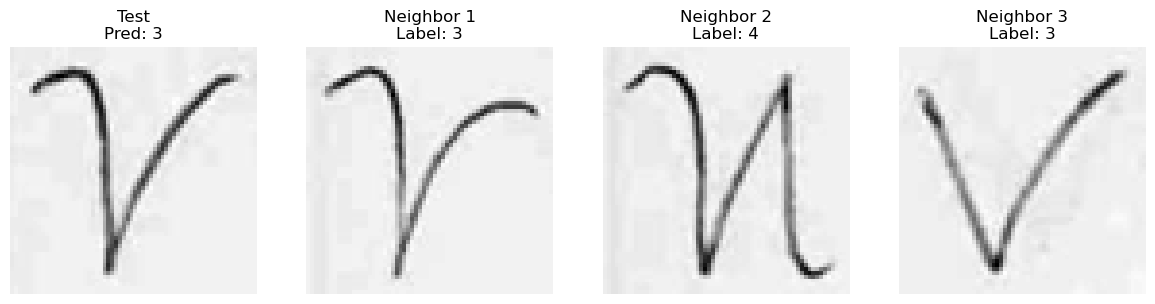

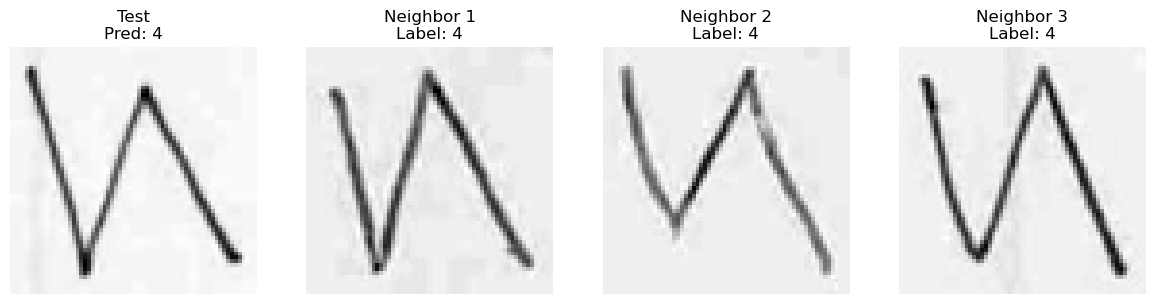

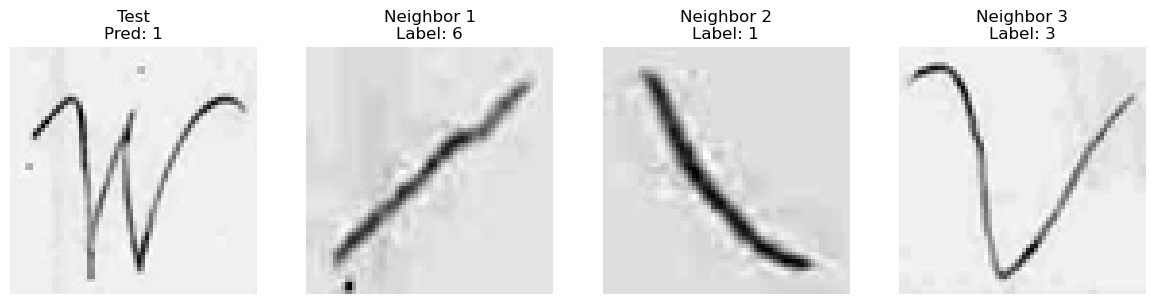

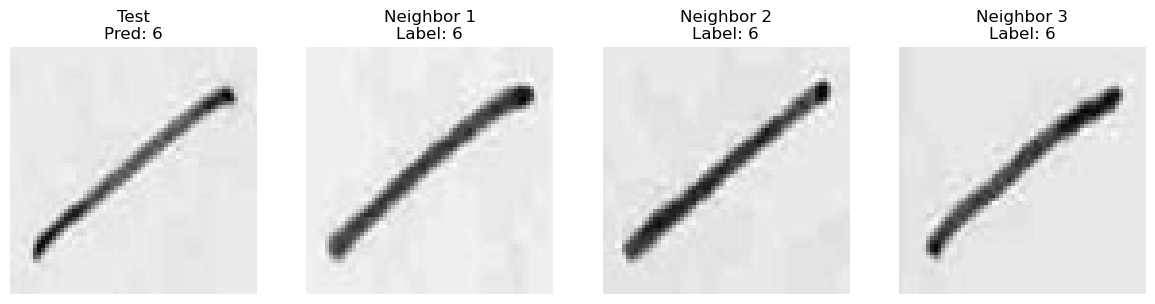

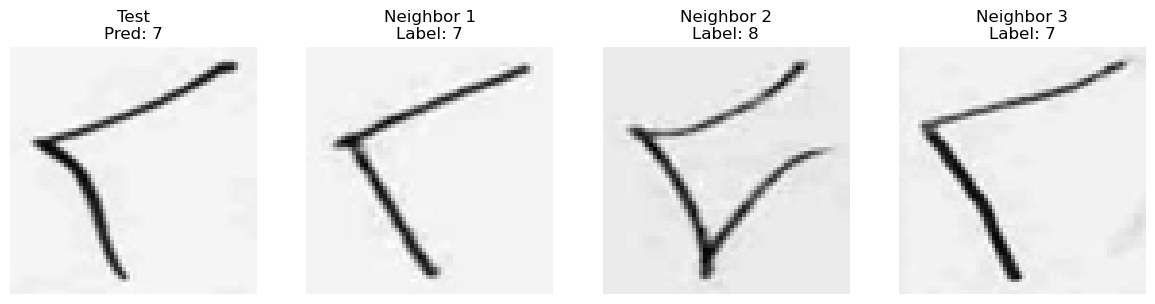

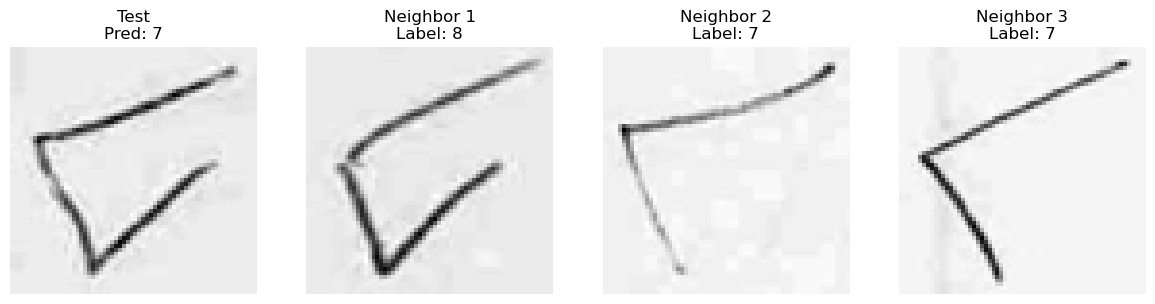

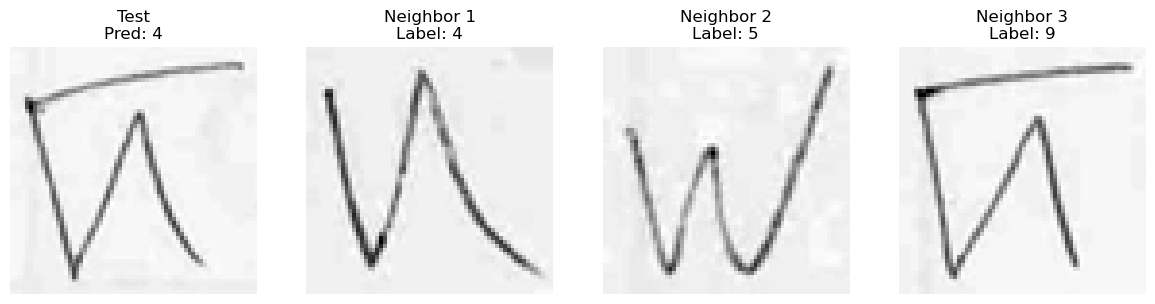

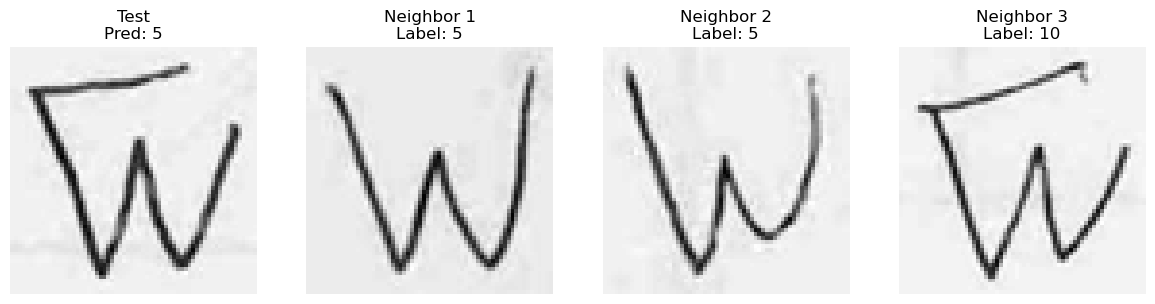

In [6]:
neighbor_dir = OUTPUT_DIR / "knn_neighbors"
for png in sorted(neighbor_dir.glob("*.png")):
    display(Image(filename=str(png)))

## 6. Short discussion

**Euclidean vs. cosine.** For both KNN and NBNN the two distance measures behaved
very similarly: the accuracies differ by only ~2–3 percentage points, with the
Euclidean variant slightly ahead in each case (KNN: 0.734 vs. 0.710; NBNN:
0.770 vs. 0.755). The Kaktovik images are grayscale symbols normalized to
$[0, 1]$ and share a similar overall brightness and scale, so the magnitude
information that cosine distance discards is not very discriminative here — neither
metric gains a clear advantage.

**KNN vs. NBNN.** NBNN edged out KNN under both metrics (e.g. 0.770 vs. 0.734 for
Euclidean, a ~3–4 point gap). NBNN scores each class by the distance to its single
nearest training sample rather than by a majority vote over the $k=3$ global
neighbours, so it is less affected by classes that happen to be densely represented
in the shared neighbourhood. The difference is noticeable but modest.

**Best classifier.** Logistic Regression was the clear winner at ~0.91, well above
all nearest-neighbour variants (best NN result ~0.77). Learning a linear decision
boundary in pixel space generalizes noticeably better on this dataset than the
purely instance-based methods, which compare raw pixel distances directly and are
more sensitive to the rotation/position variations present in the symbols.

I believe KNN suffers from the curse of dimensionality here. Because we have many pixels and each pixel is a new dimension dude. Mention it that dimensionality reduction techniques like PCA can help on this task. 